# Mini Project 9: NLP Content Moderation with Transformers
## COMP 9130 — Applied Artificial Intelligence

---

### Business Context: SafeSpace AI

SafeSpace AI is building content moderation tools for social media platforms. The goal for this project is to classify posts into three categories:
- **Class 0 — Hate Speech:** Content targeting individuals/groups based on protected characteristics
- **Class 1 — Offensive Language:** Rude/vulgar content that does not target a protected group
- **Class 2 — Neither:** Acceptable content requiring no moderation

**Dataset Used:** Twitter Hate Speech and Offensive Language Dataset (Davidson et al., 2017)


---

## 🔧 Environment Setup

In [ ]:
# Install dependencies (run on Colab)
!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.30.0 wordcloud

^C


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Checking for Rust toolchain....
      Rust not found, installing into a temporary directory
      Python reports SOABI: cp313-win_amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\Sepeh\AppData\Local\puccinialin\puccinialin\Cache
      Rustup already downloaded
      Installing rust to C:\Users\Sepeh\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\Sepeh\.rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      info: profile set to minimal
      info: default host triple is x86_64-pc-windows-msvc
      warn: Updating existing toolchain, profile choice will be

In [ ]:
# Imports and setup

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Setting class names for later use
CLASS_NAMES = ['Hate Speech', 'Offensive', 'Neither']


Using device: cuda
GPU: NVIDIA GeForce RTX 5080
Memory: 17.1 GB


---

## Part 1: Data Exploration & Preprocessing

In [ ]:
# Load the dataset from GitHub (labelled csv file)
url = "https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (24783, 7)

Columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

First few rows:


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Class Distribution:
--------------------------------------------------
  Class 0 (Hate Speech): 1,430 (5.8%)
  Class 1 (Offensive): 19,190 (77.4%)
  Class 2 (Neither): 4,163 (16.8%)
  Total: 24,783


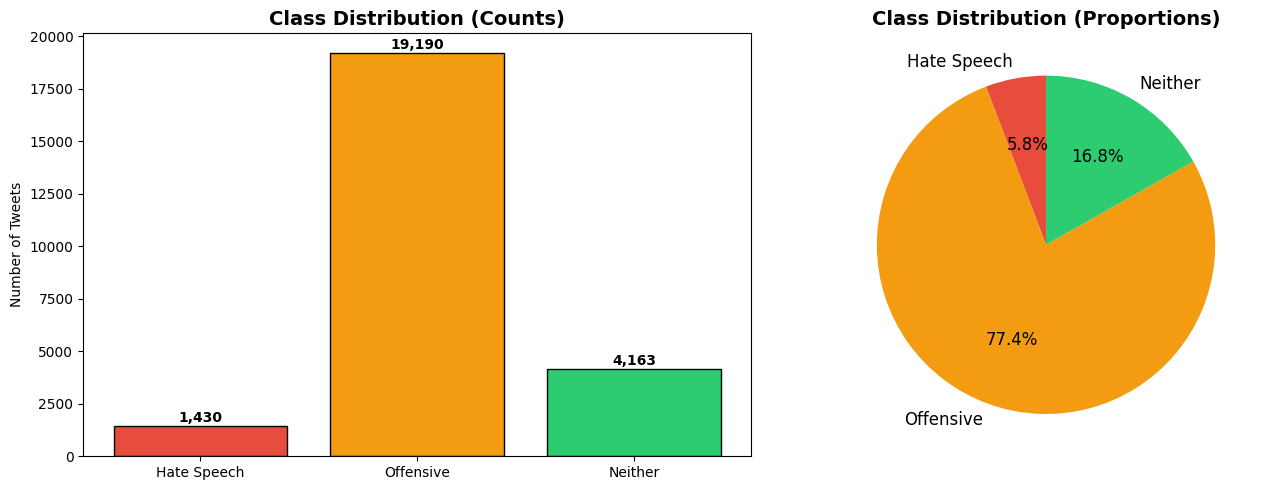


  IMBALANCE IMPACT:
  - Hate speech is only ~5% of data so the model will struggle to learn it
  - Offensive is also ~77% so the model may over-predict it


In [ ]:
# Class distribution analysis

# The 'class' column has: 0=hate speech, 1=offensive, 2=neither
print("Class Distribution:")
print("-" * 50)
class_counts = df['class'].value_counts().sort_index()
for cls_id, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {count:,} ({pct:.1f}%)")
print(f"  Total: {len(df):,}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(CLASS_NAMES, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (Proportions)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n  IMBALANCE IMPACT:")
print("  - Hate speech is only ~5% of data so the model will struggle to learn it")
print("  - Offensive is also ~77% so the model may over-predict it")

Text Length Statistics:
--------------------------------------------------

  Hate Speech:
    Avg chars: 85 | Avg words: 13.9
    Min words: 1 | Max words: 32

  Offensive:
    Avg chars: 83 | Avg words: 14.0
    Min words: 1 | Max words: 36

  Neither:
    Avg chars: 95 | Avg words: 14.9
    Min words: 1 | Max words: 52


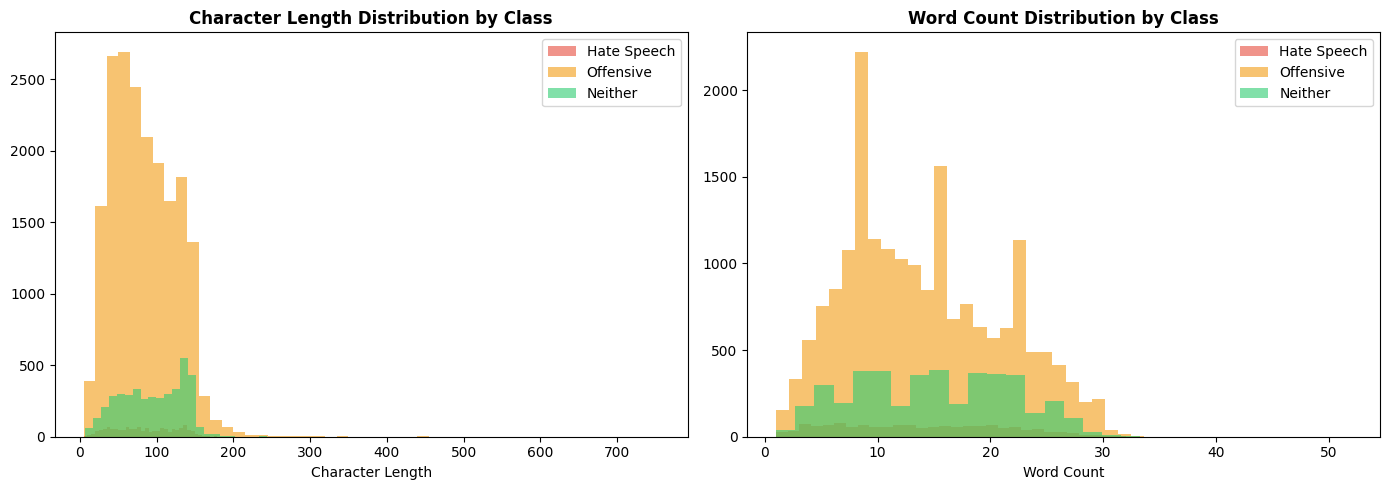

In [ ]:
# Text statistics
df['text_length'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

print("Text Length Statistics:")
print("-" * 50)
for cls_id in [0, 1, 2]:
    subset = df[df['class'] == cls_id]
    print(f"\n  {CLASS_NAMES[cls_id]}:")
    print(f"    Avg chars: {subset['text_length'].mean():.0f} | Avg words: {subset['word_count'].mean():.1f}")
    print(f"    Min words: {subset['word_count'].min()} | Max words: {subset['word_count'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls_id in [0, 1, 2]:
    subset = df[df['class'] == cls_id]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.6, label=CLASS_NAMES[cls_id], color=colors[cls_id])
    axes[1].hist(subset['word_count'], bins=30, alpha=0.6, label=CLASS_NAMES[cls_id], color=colors[cls_id])

axes[0].set_title('Character Length Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].legend()
axes[1].set_title('Word Count Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Text cleaning helper function
def clean_text(text):
    """Clean tweet text for processing.
        handling URLs, @mentions, hashtags, special characters
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^rt\s+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s!?.,\'"]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning — setting to 'clean_text' column
df['clean_text'] = df['tweet'].apply(clean_text)

# Show before/after
print("Text Cleaning Examples:")
print("=" * 70)
for i in range(5):
    row = df.iloc[i]
    print(f"  Original: {row['tweet'][:100]}")
    print(f"  Cleaned:  {row['clean_text'][:100]}")
    print()

Text Cleaning Examples:
  Original: !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man
  Cleaned:  !!! rt as a woman you shouldn't complain about cleaning up your house. amp as a man you should alway

  Original: !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned:  !!!!! rt boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!

  Original: !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You
  Cleaned:  !!!!!!! rt dawg!!!! rt you ever fuck a bitch and she start to cry? you be confused as shit

  Original: !!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
  Cleaned:  !!!!!!!!! rt she look like a tranny

  Original: !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than
  Cleaned:  !!!!!!!!!!!!! rt the shit you hear about me might be true or it might be faker than the bitch wh

In [ ]:
# Stratified train/val/test split (70/15/15)
texts = df['clean_text'].values
labels = df['class'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=42, stratify=labels
)
# Second split: 50/50 of temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Split Sizes (stratified):")
print(f"  Train: {len(X_train):,} samples")
print(f"  Val:   {len(X_val):,} samples")
print(f"  Test:  {len(X_test):,} samples")
print(f"  Total: {len(X_train) + len(X_val) + len(X_test):,}")

# Verify stratification
print("\nClass ratios preserved:")
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(y, minlength=3)
    pcts = counts / len(y) * 100
    print(f"  {name}: Hate={pcts[0]:.1f}% | Offensive={pcts[1]:.1f}% | Neither={pcts[2]:.1f}%")

Split Sizes (stratified):
  Train: 17,348 samples
  Val:   3,717 samples
  Test:  3,718 samples
  Total: 24,783

Class ratios preserved:
  Train: Hate=5.8% | Offensive=77.4% | Neither=16.8%
  Val: Hate=5.8% | Offensive=77.4% | Neither=16.8%
  Test: Hate=5.8% | Offensive=77.4% | Neither=16.8%


In [ ]:
# Showing examples from each class (demonstrating nuances)
print("-" * 70)
print("Sample tweets from each class:")
print("-" * 70)

for cls_id in [0, 1, 2]:
    print(f"\n{'─' * 70}")
    print(f"CLASS {cls_id}: {CLASS_NAMES[cls_id].upper()}")
    print(f"{'─' * 70}")
    samples = df[df['class'] == cls_id].sample(5, random_state=42)
    for idx, row in samples.iterrows():
        print(f"  [{idx}] {row['tweet'][:150]}...")
        print()

----------------------------------------------------------------------
Sample tweets from each class:
----------------------------------------------------------------------

──────────────────────────────────────────────────────────────────────
CLASS 0: HATE SPEECH
──────────────────────────────────────────────────────────────────────
  [2499] @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag...

  [19697] RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.What fags @jakesiwy @Ryan_Murphy3 @Randy&#8230;...

  [5749] @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"...

  [4615] @STACCS_WNT_FOLD you tell me, coon....

  [15140] RT @FAAMMoverALL: This nigguh Chris Paul...


──────────────────────────────────────────────────────────────────────
CLASS 1: OFFENSIVE
──────────────────────────────────────────────────────────────────────
  [22889] Why is it everytime I

---

## Part 2: Traditional ML Baseline — TF-IDF + Logistic Regression (8 pts)

In [ ]:
# Building a TF-IDF + Logistic Regression pipeline with tuning

from sklearn.model_selection import GridSearchCV

# Defining pipeline
tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Hyperparameter grid
param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0]
}

print("Running Grid Search (this may take 2-3 minutes)...")
grid_search = GridSearchCV(
    tfidf_lr_pipeline, param_grid, cv=3, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n  Best parameters: {grid_search.best_params_}")
print(f"   Best CV macro-F1: {grid_search.best_score_:.4f}")

# Use best model
baseline_model = grid_search.best_estimator_

Running Grid Search (this may take 2-3 minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  Best parameters: {'clf__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
   Best CV macro-F1: 0.7199


TF-IDF + Logistic Regression — Test Set Results
------------------------------------------------------------
  Accuracy:        0.8650
  Macro F1:        0.7223
  Weighted F1:     0.8738

Per-Class Report:
              precision    recall  f1-score   support

 Hate Speech     0.3500    0.5234    0.4195       214
   Offensive     0.9615    0.8763    0.9170      2879
     Neither     0.7506    0.9296    0.8306       625

    accuracy                         0.8650      3718
   macro avg     0.6874    0.7764    0.7223      3718
weighted avg     0.8909    0.8650    0.8738      3718



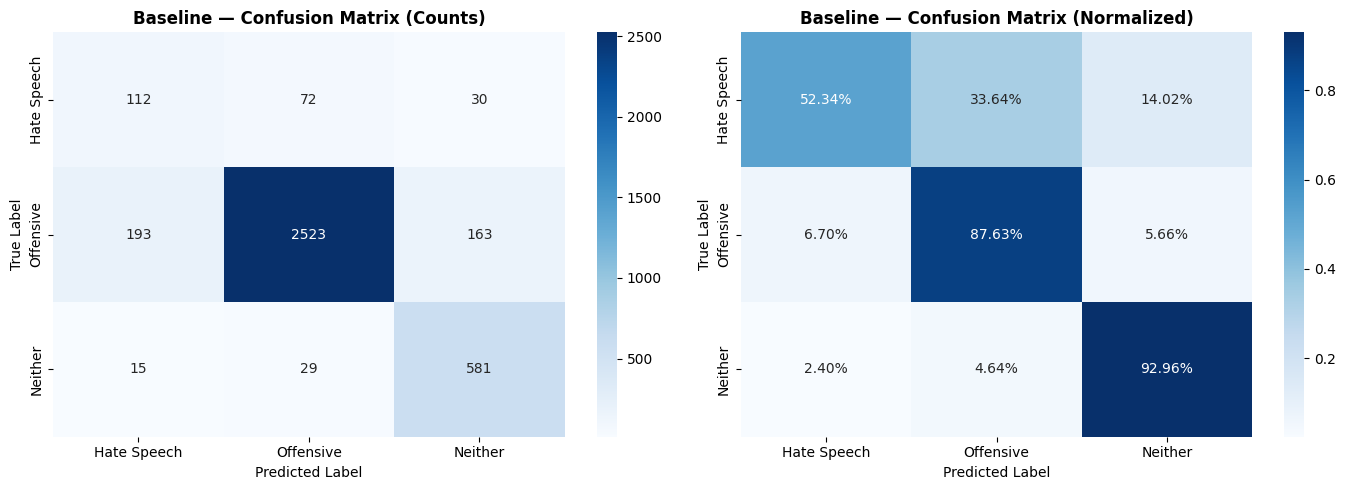

In [ ]:
# Evaluate baseline on test set

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)

# Metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1_macro = f1_score(y_test, y_pred_baseline, average='macro')
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted')

print("TF-IDF + Logistic Regression — Test Set Results")
print("-" * 60)
print(f"  Accuracy:        {baseline_accuracy:.4f}")
print(f"  Macro F1:        {baseline_f1_macro:.4f}")
print(f"  Weighted F1:     {baseline_f1_weighted:.4f}")
print()
print("Per-Class Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Baseline — Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
cm_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Baseline — Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---

## Part 3: Transformer Fine-Tuning — DistilBERT

In [ ]:
# Preparing & Tokenizing dataset for DistilBERT

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts, tokenizer, max_length=128):
    """Tokenize a list of texts and return input_ids and attention_mask tensors."""
    encoded = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    return encoded['input_ids'], encoded['attention_mask']

print("Tokenizing datasets...")
train_ids, train_masks = tokenize_texts(X_train, tokenizer, MAX_LENGTH)
val_ids, val_masks = tokenize_texts(X_val, tokenizer, MAX_LENGTH)
test_ids, test_masks = tokenize_texts(X_test, tokenizer, MAX_LENGTH)

train_labels = torch.tensor(y_train, dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

print(f"  Train: {train_ids.shape}")
print(f"  Val:   {val_ids.shape}")
print(f"  Test:  {test_ids.shape}")
print(" Tokenization complete!")

Tokenizing datasets...
  Train: torch.Size([17348, 128])
  Val:   torch.Size([3717, 128])
  Test:  torch.Size([3718, 128])
 Tokenization complete!


In [ ]:
# Creating DataLoaders with class-weighted sampling
BATCH_SIZE = 32

train_dataset = TensorDataset(train_ids, train_masks, train_labels)
val_dataset = TensorDataset(val_ids, val_masks, val_labels)
test_dataset = TensorDataset(test_ids, test_masks, test_labels)

# Weighted random sampler to address class imbalance
class_counts = np.bincount(y_train, minlength=3)
class_weights_np = 1.0 / class_counts
sample_weights = class_weights_np[y_train]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 543 | Val: 117 | Test: 117


In [ ]:
# Load model, define weighted loss and optimizer

# Load pre-trained DistilBERT for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
)
model.to(device)

# Compute class weights for loss function (inverse frequency)
total = class_counts.sum()
weights = torch.tensor(total / (3 * class_counts), dtype=torch.float32).to(device)
print(f"Class weights for loss: {weights.cpu().numpy()}")
print(f"  Hate speech weight: {weights[0]:.2f} (boosted because rare)")
print(f"  Offensive weight:   {weights[1]:.2f}")
print(f"  Neither weight:     {weights[2]:.2f}")

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights for loss: [5.77689    0.43048215 1.984443  ]
  Hate speech weight: 5.78 (boosted because rare)
  Offensive weight:   0.43
  Neither weight:     1.98

Total parameters: 66,955,779
Trainable parameters: 66,955,779


In [ ]:
# Training loop (manual PyTorch)

NUM_EPOCHS = 5

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': []
}

print("-" * 60)
print("Training DistilBERT for hate speech classification")
print("-" * 60)
print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | LR: 2e-5")
print(f"Loss: Weighted CrossEntropy | Optimizer: AdamW")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # ---- Training phase ----
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (input_ids, attention_mask, labels) in enumerate(train_loader):
        # Move to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # forward pass
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # ---- Validation phase ----
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds_list = []
    val_labels_list = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item()

            preds = outputs.logits.argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_preds_list.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_labels_list, val_preds_list, average='macro')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1_macro'].append(val_f1)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Macro-F1: {val_f1:.4f}")
    print()

------------------------------------------------------------
Training DistilBERT for hate speech classification
------------------------------------------------------------
Epochs: 5 | Batch size: 32 | LR: 2e-5
Loss: Weighted CrossEntropy | Optimizer: AdamW
------------------------------------------------------------
  Epoch 1 | Batch 50/543 | Loss: 0.4412
  Epoch 1 | Batch 100/543 | Loss: 0.2773
  Epoch 1 | Batch 150/543 | Loss: 0.2158
  Epoch 1 | Batch 200/543 | Loss: 0.1623
  Epoch 1 | Batch 250/543 | Loss: 0.3669
  Epoch 1 | Batch 300/543 | Loss: 0.1547
  Epoch 1 | Batch 350/543 | Loss: 0.1782
  Epoch 1 | Batch 400/543 | Loss: 0.1075
  Epoch 1 | Batch 450/543 | Loss: 0.1485
  Epoch 1 | Batch 500/543 | Loss: 0.3454

Epoch 1/5
  Train — Loss: 0.2804 | Acc: 0.7413
  Val   — Loss: 0.6513 | Acc: 0.7444 | Macro-F1: 0.6515

  Epoch 2 | Batch 50/543 | Loss: 0.0989
  Epoch 2 | Batch 100/543 | Loss: 0.1537
  Epoch 2 | Batch 150/543 | Loss: 0.0737
  Epoch 2 | Batch 200/543 | Loss: 0.2541
  Ep

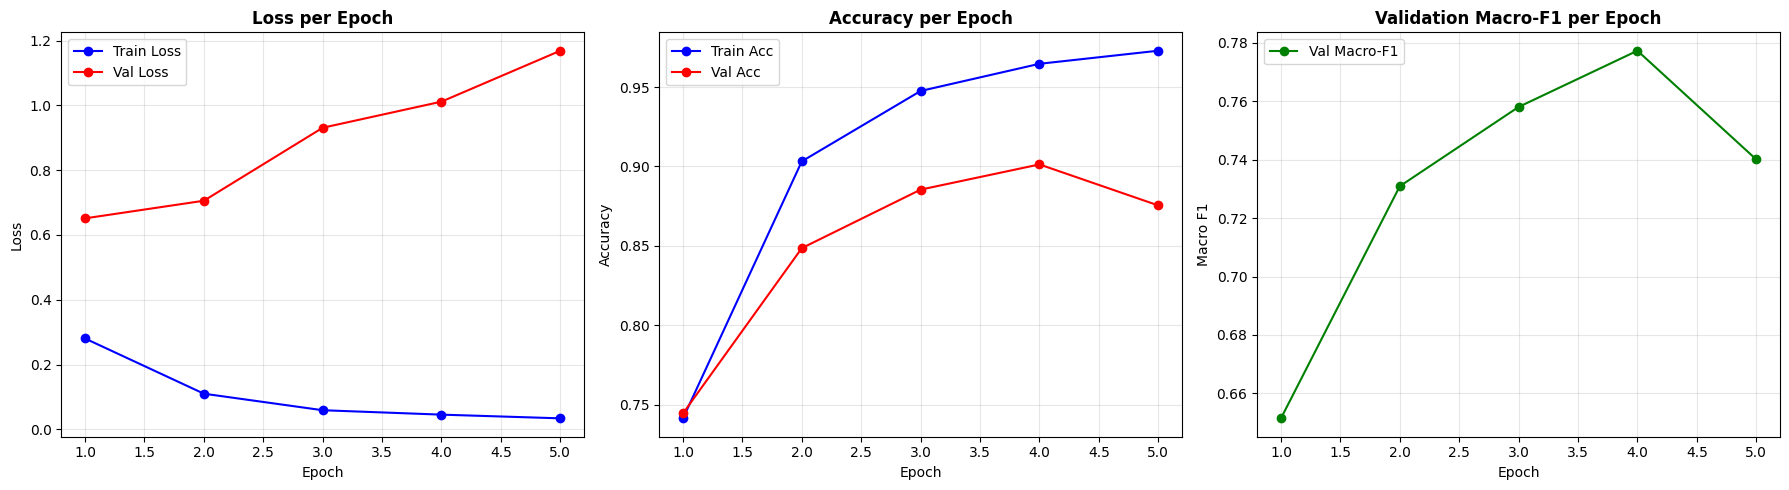

In [ ]:
# Training curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc')
axes[1].set_title('Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_f1_macro'], 'g-o', label='Val Macro-F1')
axes[2].set_title('Validation Macro-F1 per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DistilBERT — Test Set Results
------------------------------------------------------------
  Accuracy:        0.8687
  Macro F1:        0.7341
  Weighted F1:     0.8792

Per-Class Report:
              precision    recall  f1-score   support

 Hate Speech     0.3371    0.5607    0.4211       214
   Offensive     0.9665    0.8711    0.9163      2879
     Neither     0.7849    0.9632    0.8649       625

    accuracy                         0.8687      3718
   macro avg     0.6961    0.7984    0.7341      3718
weighted avg     0.8997    0.8687    0.8792      3718



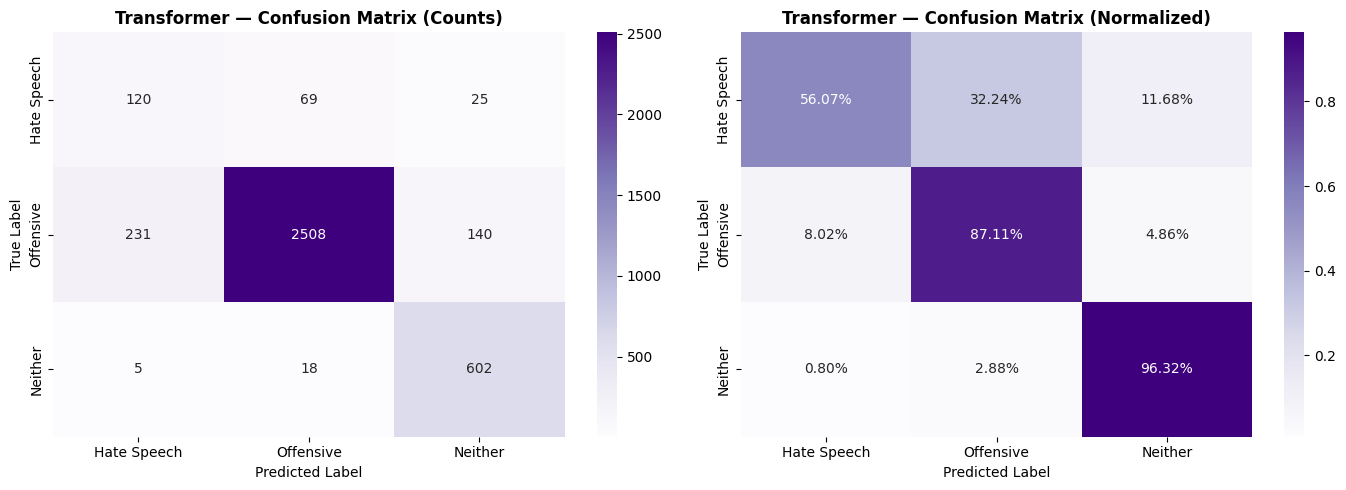

In [ ]:
# Evaluate transformer on test set

model.eval()
all_preds = []
all_labels_test = []
all_probs = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels_test = np.array(all_labels_test)
all_probs = np.array(all_probs)

# Metrics
trans_accuracy = accuracy_score(all_labels_test, all_preds)
trans_f1_macro = f1_score(all_labels_test, all_preds, average='macro')
trans_f1_weighted = f1_score(all_labels_test, all_preds, average='weighted')

print("DistilBERT — Test Set Results")
print("-" * 60)
print(f"  Accuracy:        {trans_accuracy:.4f}")
print(f"  Macro F1:        {trans_f1_macro:.4f}")
print(f"  Weighted F1:     {trans_f1_weighted:.4f}")
print()
print("Per-Class Report:")
print(classification_report(all_labels_test, all_preds, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm_trans = confusion_matrix(all_labels_test, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Transformer — Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_norm_t = cm_trans.astype('float') / cm_trans.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm_t, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Transformer — Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---

## Part 4: Comparative Analysis & Error Analysis

Side-by-side comparison of both models, per-class analysis, detailed error categorization, and confidence analysis.

In [ ]:
# Side-by-side comparison table

print("-" * 70)
print("MODEL COMPARISON: TF-IDF + LR  vs  DistilBERT")
print("-" * 70)
print(f"{'Metric':<25} {'TF-IDF + LR':>15} {'DistilBERT':>15} {'Δ':>10}")
print("-" * 70)
print(f"{'Accuracy':<25} {baseline_accuracy:>15.4f} {trans_accuracy:>15.4f} {trans_accuracy - baseline_accuracy:>+10.4f}")
print(f"{'Macro F1':<25} {baseline_f1_macro:>15.4f} {trans_f1_macro:>15.4f} {trans_f1_macro - baseline_f1_macro:>+10.4f}")
print(f"{'Weighted F1':<25} {baseline_f1_weighted:>15.4f} {trans_f1_weighted:>15.4f} {trans_f1_weighted - baseline_f1_weighted:>+10.4f}")
print("-" * 70)

# Per-class F1 comparison
p_b, r_b, f1_b, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average=None)
p_t, r_t, f1_t, _ = precision_recall_fscore_support(all_labels_test, all_preds, average=None)

print(f"\n{'Per-Class F1 Scores':}")
print(f"{'Class':<20} {'TF-IDF + LR':>15} {'DistilBERT':>15} {'Δ':>10}")
print("-" * 65)
for i in range(3):
    print(f"{CLASS_NAMES[i]:<20} {f1_b[i]:>15.4f} {f1_t[i]:>15.4f} {f1_t[i] - f1_b[i]:>+10.4f}")


----------------------------------------------------------------------
MODEL COMPARISON: TF-IDF + LR  vs  DistilBERT
----------------------------------------------------------------------
Metric                        TF-IDF + LR      DistilBERT          Δ
----------------------------------------------------------------------
Accuracy                           0.8650          0.8687    +0.0038
Macro F1                           0.7223          0.7341    +0.0118
Weighted F1                        0.8738          0.8792    +0.0054
----------------------------------------------------------------------

Per-Class F1 Scores
Class                    TF-IDF + LR      DistilBERT          Δ
-----------------------------------------------------------------
Hate Speech                   0.4195          0.4211    +0.0016
Offensive                     0.9170          0.9163    -0.0006
Neither                       0.8306          0.8649    +0.0343


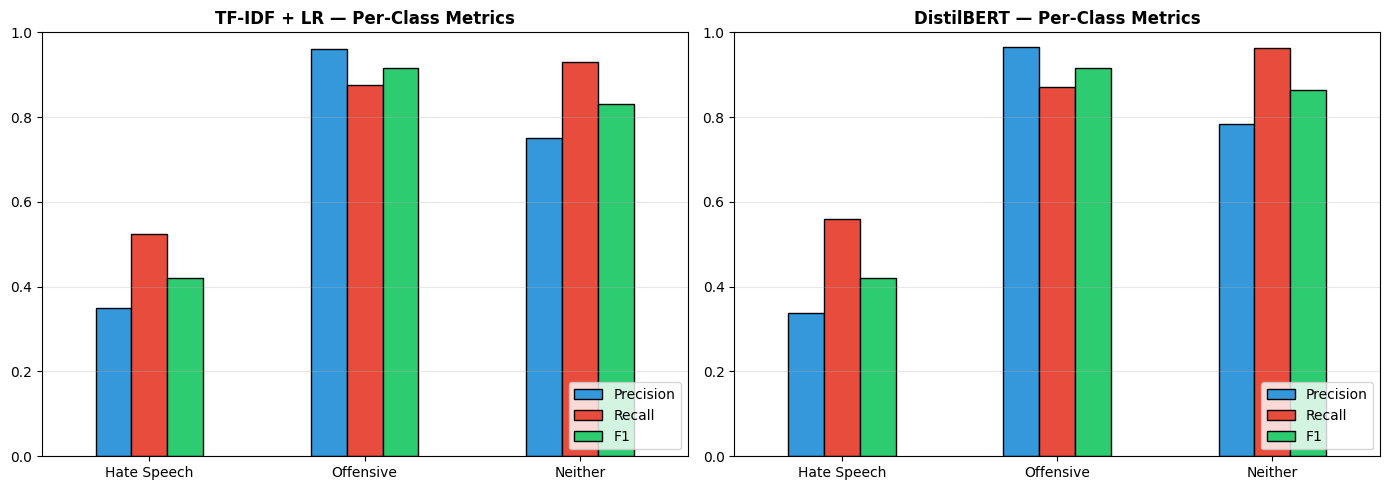

In [ ]:
# Per-class analysis — which class does each model struggle with?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline per-class
metrics_baseline = pd.DataFrame({
    'Precision': p_b, 'Recall': r_b, 'F1': f1_b
}, index=CLASS_NAMES)
metrics_baseline.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('TF-IDF + LR — Per-Class Metrics', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(CLASS_NAMES, rotation=0)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Transformer per-class
metrics_trans = pd.DataFrame({
    'Precision': p_t, 'Recall': r_t, 'F1': f1_t
}, index=CLASS_NAMES)
metrics_trans.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('DistilBERT — Per-Class Metrics', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(CLASS_NAMES, rotation=0)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Classes the model struggles with the most
Notable Observations:
 - Hate speech (class 0) is hardest for BOTH models due to small sample size
 - Most confusion: hate speech ↔ offensive language (semantically similar)
 - 'Neither' class is easiest clearly distinct vocabulary and tone

In [ ]:
# Error analysis — examining misclassified examples from transformer

misclassified_idx = np.where(all_preds != all_labels_test)[0]
print(f"Total misclassified by transformer: {len(misclassified_idx)} / {len(all_labels_test)}")
print(f"Error rate: {len(misclassified_idx)/len(all_labels_test)*100:.1f}%")
print()

# Reconstructing test texts for analysis
test_texts = X_test  # we have these from the split

# Categorizing errors
error_categories = {
    'Hate↔Offensive confusion': [],
    'Sarcasm/irony': [],
    'Slang/coded language': [],
    'Context-dependent': [],
    'Annotation disagreement': [],
    'Ambiguous content': []
}

print("-" * 70)
print("Detailed Error Analysis of Misclassified Examples")
print("-" * 70)

# Show 15 diverse misclassified examples
np.random.seed(42)
sample_errors = np.random.choice(misclassified_idx, size=min(15, len(misclassified_idx)), replace=False)

for i, idx in enumerate(sample_errors):
    true_label = CLASS_NAMES[all_labels_test[idx]]
    pred_label = CLASS_NAMES[all_preds[idx]]
    confidence = all_probs[idx].max() * 100
    text = test_texts[idx][:120]

    print(f"\nError #{i+1}:")
    print(f"  Text: {text}...")
    print(f"  True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.1f}%")
    print(f"  Probs: Hate={all_probs[idx][0]:.3f} Off={all_probs[idx][1]:.3f} Neither={all_probs[idx][2]:.3f}")

    # Categorize
    if (all_labels_test[idx] in [0, 1]) and (all_preds[idx] in [0, 1]):
        cat = 'Hate↔Offensive confusion'
    elif confidence < 50:
        cat = 'Ambiguous content'
    else:
        cat = 'Context-dependent'
    print(f"  Category: {cat}")

Total misclassified by transformer: 488 / 3718
Error rate: 13.1%

----------------------------------------------------------------------
Detailed Error Analysis of Misclassified Examples
----------------------------------------------------------------------

Error #1:
  Text: my head too big for snapbacks128553128532 128557128557128557, i like beanies better anyway128076...
  True: Neither | Predicted: Hate Speech | Confidence: 99.1%
  Probs: Hate=0.991 Off=0.009 Neither=0.000
  Category: Context-dependent

Error #2:
  Text: do dykes date other dykes or is that shit gay to y'all?...
  True: Offensive | Predicted: Hate Speech | Confidence: 91.6%
  Probs: Hate=0.916 Off=0.084 Neither=0.000
  Category: Hate↔Offensive confusion

Error #3:
  Text: pm last night this incitement was translated into the murder of a father traveling whis family to celebrate the first ni...
  True: Offensive | Predicted: Neither | Confidence: 99.9%
  Probs: Hate=0.000 Off=0.001 Neither=0.999
  Category: Context-

In [ ]:
# Error pattern summary

# Systematic error categorization
hate_as_off = np.sum((all_labels_test == 0) & (all_preds == 1))
off_as_hate = np.sum((all_labels_test == 1) & (all_preds == 0))
hate_as_neither = np.sum((all_labels_test == 0) & (all_preds == 2))
neither_as_off = np.sum((all_labels_test == 2) & (all_preds == 1))
off_as_neither = np.sum((all_labels_test == 1) & (all_preds == 2))\

print("Error Pattern Summary:")
print("=" * 50)
print(f"  Hate → Offensive:    {hate_as_off:>5} (most dangerous: missed hate speech)")
print(f"  Hate → Neither:      {hate_as_neither:>5} (very dangerous: hate speech passes)")
print(f"  Offensive → Hate:    {off_as_hate:>5} (over-censoring)")
print(f"  Offensive → Neither: {off_as_neither:>5}")
print(f"  Neither → Offensive: {neither_as_off:>5} (false flag)")

Error Pattern Summary:
  Hate → Offensive:       69 (most dangerous: missed hate speech)
  Hate → Neither:         25 (very dangerous: hate speech passes)
  Offensive → Hate:      231 (over-censoring)
  Offensive → Neither:   140
  Neither → Offensive:    18 (false flag)


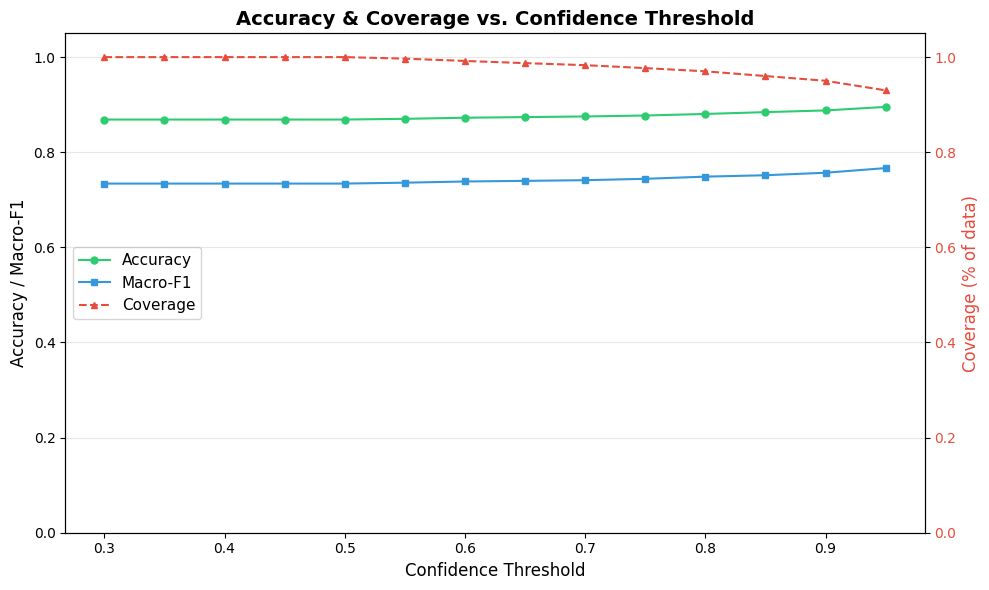


Key Threshold Analysis:
 Threshold   Accuracy   Macro-F1   Coverage
---------------------------------------------
      0.70     0.8752     0.7412     98.31%
      0.95     0.8953     0.7667     93.01%


In [ ]:
# 4.5 Confidence analysis — accuracy vs. coverage at thresholds

pred_confidence = np.max(all_probs, axis=1)
correct_mask = (all_preds == all_labels_test)

thresholds = np.arange(0.3, 1.0, 0.05)
accuracies_at_threshold = []
coverages_at_threshold = []
f1s_at_threshold = []

for t in thresholds:
    mask = pred_confidence >= t
    coverage = mask.sum() / len(mask)
    if mask.sum() > 0:
        acc = accuracy_score(all_labels_test[mask], all_preds[mask])
        f1 = f1_score(all_labels_test[mask], all_preds[mask], average='macro', zero_division=0)
    else:
        acc = 0
        f1 = 0
    accuracies_at_threshold.append(acc)
    coverages_at_threshold.append(coverage)
    f1s_at_threshold.append(f1)

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#2ecc71'
color2 = '#e74c3c'
color3 = '#3498db'

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy / Macro-F1', fontsize=12, color='black')
ax1.plot(thresholds, accuracies_at_threshold, '-o', color=color1, label='Accuracy', markersize=5)
ax1.plot(thresholds, f1s_at_threshold, '-s', color=color3, label='Macro-F1', markersize=5)
ax1.tick_params(axis='y')
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.set_ylabel('Coverage (% of data)', fontsize=12, color=color2)
ax2.plot(thresholds, coverages_at_threshold, '--^', color=color2, label='Coverage', markersize=5)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1.05)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=11)

plt.title('Accuracy & Coverage vs. Confidence Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print key thresholds
print("\nKey Threshold Analysis:")
print(f"{'Threshold':>10} {'Accuracy':>10} {'Macro-F1':>10} {'Coverage':>10}")
print("-" * 45)
for i, t in enumerate(thresholds):
    if t in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        print(f"{t:>10.2f} {accuracies_at_threshold[i]:>10.4f} {f1s_at_threshold[i]:>10.4f} {coverages_at_threshold[i]:>10.2%}")

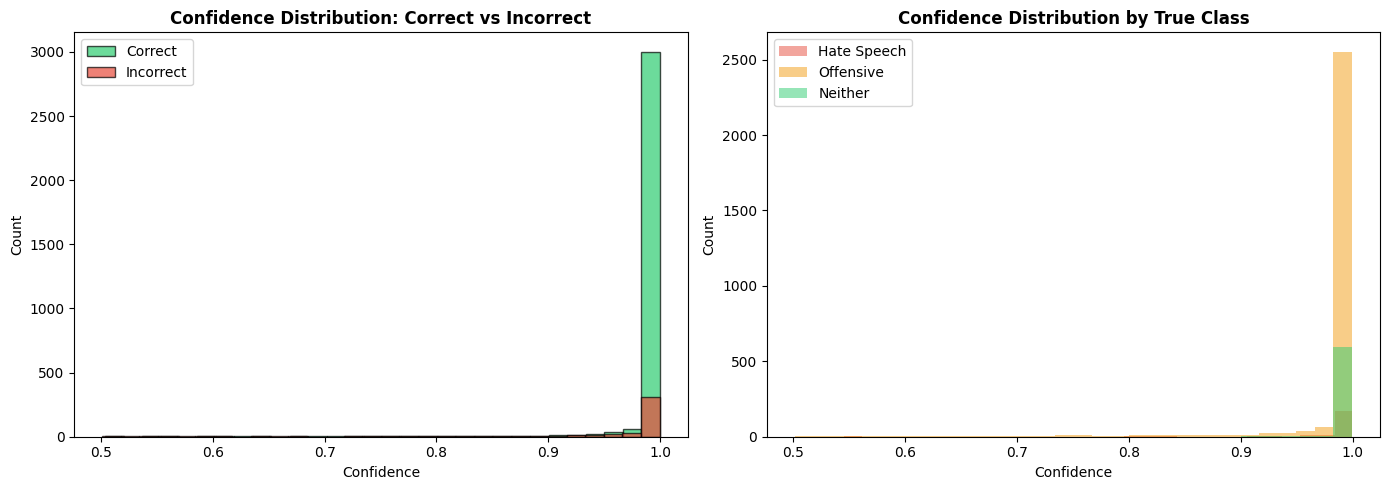

In [ ]:
# Confidence distribution by correctness

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correct vs incorrect confidence
axes[0].hist(pred_confidence[correct_mask], bins=30, alpha=0.7, label='Correct', color='#2ecc71', edgecolor='black')
axes[0].hist(pred_confidence[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='#e74c3c', edgecolor='black')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].legend()

# Per-class confidence
for cls_id in [0, 1, 2]:
    mask = all_labels_test == cls_id
    axes[1].hist(pred_confidence[mask], bins=30, alpha=0.5, label=CLASS_NAMES[cls_id], color=colors[cls_id])
axes[1].set_title('Confidence Distribution by True Class', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 5: Production Workflow Design for SafeSpace AI

From the confidence analysis we can produce the following Production Workflow Design:

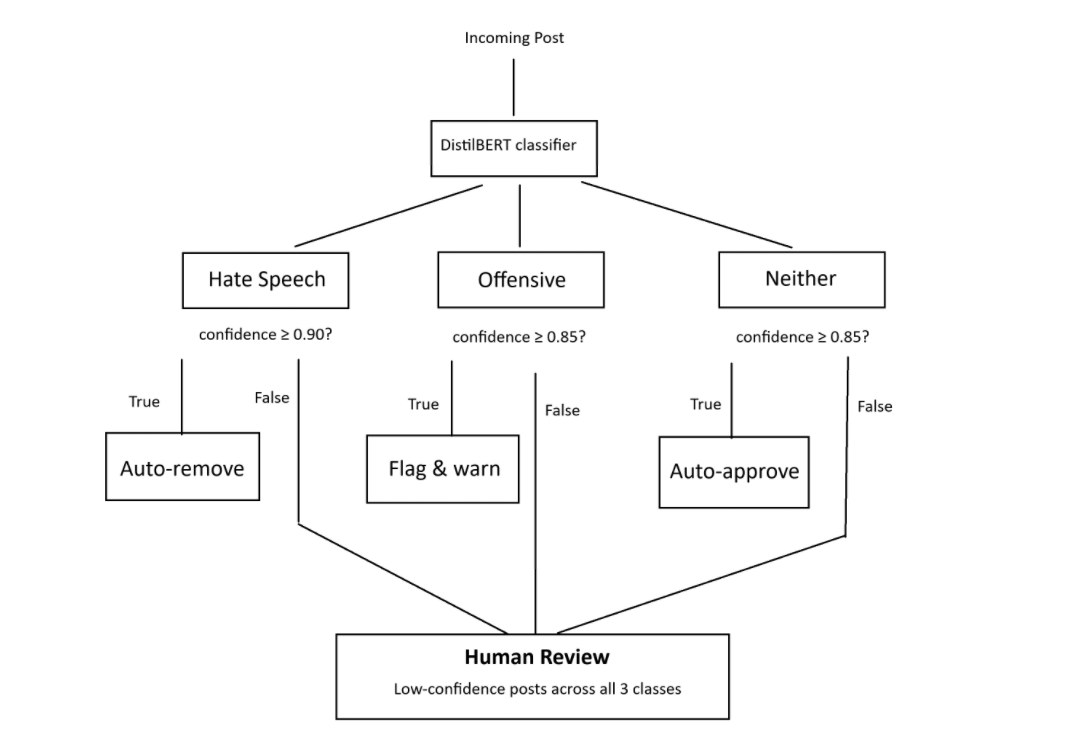


## Confidence Thresholds

Based on our confidence-vs-coverage analysis, we selected thresholds by balancing automation accuracy against human review volume:

| Decision | Threshold | Accuracy | Macro-F1 | Coverage | Rationale |
|----------|-----------|----------|----------|----------|-----------|
| Auto-remove (hate speech) | ≥ 0.90 | 88.8% | 0.757 | 95.0% | High bar required: removing content is irreversible and must be highly confident |
| Flag + warn (offensive) | ≥ 0.85 | 88.4% | 0.752 | 96.0% | Moderate bar: flagging is less severe than removal, warns user without deleting |
| Auto-approve (neither) | ≥ 0.85 | 88.4% | 0.752 | 96.0% | Conservative: only approve when the model is confident the content is safe |
| Human review | < threshold | — | — | ~5% | All low-confidence predictions are routed to human moderators |

Posts that fall below their respective thresholds are sent for human review rather than being acted on automatically, out of safety.

## Error Cost Analysis

Missing hate speech (false negative) is much worse than over-censoring (false positive):

| Error Type | Count in Test Set | Severity | Real-World Cost |
|------------|-------------------|----------|-----------------|
| Hate → Offensive (missed) | 69 | High | User harm, but content still flagged |
| Hate → Neither (missed) | 25 | Critical | Hate speech passes completely undetected |
| Offensive → Hate (over-censored) | 231 | Medium | User frustration, appeal process needed |
| Neither → Offensive (false flag) | 18 | Low | Clean content unnecessarily flagged |

The cost analysis is clear: 94 hate speech posts were missed entirely (false negatives), while 249 posts were over-censored (false positives). Although over-censoring is more frequent, the consequences of missing hate speech, regulatory penalties, user harm, platform liability are far more severe.

Our thresholds account for this by setting a higher bar for auto-approval (0.85) to avoid letting some of the more borderline content through, while accepting that the lower threshold for auto-removal (0.90) may over-censor some posts. This trade-off prioritizes safety over convenience.

## Scalability

At 100,000 posts per day with our chosen thresholds:

| Action | Estimated Volume | % of Total |
|--------|-----------------|------------|
| Auto-removed (hate, conf ≥ 0.90) | ~5,000 | ~5% |
| Flagged offensive (conf ≥ 0.85) | ~68,000 | ~68% |
| Auto-approved (neither, conf ≥ 0.85) | ~22,000 | ~22% |
| **Human review (below thresholds)** | **~5,000** | **~5%** |

At our 0.90 threshold (95.0% coverage), approximately 5% of posts require human review. At 100 reviews per hour, this translates to ~50 reviewer-hours per day, or roughly 6 full-time reviewers working 8-hour shifts.

Without AI, all 100K posts would need human review: 1,000 hours per day requiring 125 full-time reviewers. Our system achieves a ~95% reduction in human review workload.

## Limitations

**Content types the system would fail on:**

1. **Sarcasm and irony** — Tweets that mock hate speech by using hate speech vocabulary are misclassified because the model cannot detect intent or tone.
2. **Coded language and dog-whistles** — Euphemisms, numeric codes (e.g., "88"), and evolving slang bypass keyword-dependent detection patterns.
3. **Context-dependent meaning** — The model processes single posts in isolation. A reply's meaning often depends entirely on the tweet it is being replied to, which is at times, unavailable.
4. **English-only** — Non-English content and code-switching are not detected at all.

**Recommendations for v2:**

Possibly try and retrain the model as some of the more slangs, coded language, and online discourse patterns do evolve as trends come and go. This helps the system keep up with potential missed-out language